In [1]:
import pandas as pd
from sklearn.metrics import auc, roc_curve
import yaml
import os
from sklearn.metrics import auc
from statistics import mean 

In [2]:
def calculate_auc_avg(tickers, predictions, true_values):
    predictions = predictions.sort_values(by='fecha')
    true_values = true_values.sort_values(by='fecha')
    
    
    # renombro las columnas
    column_names = {}
    for column in predictions.columns:
        if column != 'fecha':
            column_names[column] = f'{column}_proba'
    
    predictions = predictions.rename(columns=column_names)
    
    column_names = {}
    for column in true_values.columns:
        if column != 'fecha':
            column_names[column] = f'{column}_true'
    
    true_values = true_values.rename(columns=column_names)
    performance = pd.concat(
        [
            predictions,
            true_values
        ], axis=1, join="inner"
    )
    
    auc_list = []
    for ticker in tickers:
        y_true = performance[performance[f'{ticker}_true'].notna()][f'{ticker}_true']
        y_pred = performance[performance[f'{ticker}_proba'].notna()][f'{ticker}_proba']
        
        fpr, tpr, thresholds = roc_curve(y_true, y_pred)
        auc_score = auc(fpr, tpr)
        
        auc_list.append(auc_score)

    return mean(auc_list)


def max_drawdown(serie):
    max_valor_acumulado = serie[0]
    max_dd = 0

    for valor_actual in serie[1:]:
        if valor_actual > max_valor_acumulado:
            max_valor_acumulado = valor_actual
        else:
            dd = (max_valor_acumulado - valor_actual) / max_valor_acumulado
            if dd > max_dd:
                max_dd = dd

    return max_dd

In [3]:
with open('configs/project_config.yml', 'r') as archivo:
    config = yaml.safe_load(archivo)

tickers = config["tickers"] 
tickers

['YPF', 'BBAR', 'BMA', 'CEPU', 'EDN', 'TEO', 'LOMA']

In [4]:
results_dict = {}

for path in os.listdir('./data'):
    if not path.endswith('.csv') and path.startswith('mode_train'):
        print(path)
        results_dict[path] = {}

        try:
            initial_wallet_value = 100
            wallet = pd.read_csv(os.path.join('./data', path, 'wallet.csv'))
            final_wallet_value = wallet.tail(1).iloc[0]['wallet']

            results_dict[path]['wallet'] = ((final_wallet_value - initial_wallet_value) / initial_wallet_value) * 100
            results_dict[path]['max_drawdown'] = max_drawdown(wallet['wallet'])
        except:
            results_dict[path]['wallet'] = 0

        try:
            orders = pd.read_csv(os.path.join('./data', path, 'orders.csv'))
            results_dict[path]['buys'] = orders[orders['open_date'].notna()].shape[0]
            results_dict[path]['sells'] = orders[orders['close_date'].notna()].shape[0]
           
            avg_incomes = orders.groupby('ticker')['profit'].sum().mean()
            results_dict[path]['avg_incomes'] = avg_incomes
            results_dict[path]['avg_incomes_norm'] = avg_incomes / abs(orders['profit'].max())
            results_dict[path]['good_operations'] = orders[orders['profit'] > 0].shape[0]
            results_dict[path]['bad_operations'] = orders[orders['profit'] <= 0].shape[0]

            results_dict[path]['total_operations'] = orders.shape[0]

            results_dict[path]['winning_rate'] = results_dict[path]['good_operations'] / (results_dict[path]['good_operations'] + results_dict[path]['bad_operations']) 
            
        except:
            results_dict[path]['buys'] = 0
            results_dict[path]['sells'] = 0
            avg_incomes = 0
            results_dict[path]['avg_incomes'] = 0
            results_dict[path]['good_operations'] = 0
            results_dict[path]['bad_operations'] = 0
            results_dict[path]['winning_rate'] = 0

        try:
            train_results = pd.read_csv(os.path.join('./data', path, 'train_results.csv'))
            avg_train_auc = train_results['auc'].mean()
            results_dict[path]['avg_train_auc'] = avg_train_auc
        except:
            results_dict[path]['avg_train_auc'] = 0
            
        try:
            stock_predictions = pd.read_csv(os.path.join('./data', path, 'stock_predictions.csv'))
            true_values = pd.read_csv(os.path.join('./data', path, 'stock_true_values.csv'))

            avg_auc_score = calculate_auc_avg(tickers, stock_predictions, true_values)
            results_dict[path]['avg_test_auc'] = avg_auc_score
        except:
            results_dict[path]['avg_test_auc'] = 0

results = pd.DataFrame.from_dict(results_dict, orient='index')

mode_train-model_gradient_boosting-trainwindow_114-trainperiod_14-tradingstrategy_strategies.bband_strategy
mode_train-model_gradient_boosting-trainwindow_114-trainperiod_14-tradingstrategy_strategies.macd_strategy
mode_train-model_gradient_boosting-trainwindow_114-trainperiod_14-tradingstrategy_strategies.ma_strategy
mode_train-model_gradient_boosting-trainwindow_114-trainperiod_14-tradingstrategy_strategies.ml_strategy
mode_train-model_gradient_boosting-trainwindow_114-trainperiod_30-tradingstrategy_strategies.bband_strategy
mode_train-model_gradient_boosting-trainwindow_114-trainperiod_30-tradingstrategy_strategies.macd_strategy
mode_train-model_gradient_boosting-trainwindow_114-trainperiod_30-tradingstrategy_strategies.ma_strategy
mode_train-model_gradient_boosting-trainwindow_114-trainperiod_30-tradingstrategy_strategies.ml_strategy
mode_train-model_gradient_boosting-trainwindow_114-trainperiod_7-tradingstrategy_strategies.bband_strategy
mode_train-model_gradient_boosting-trainwin

In [5]:
ypf = pd.read_csv('./data/YPF.csv')

In [6]:
beta = 0.05
results['buy_ratio'] = results['buys'] / (ypf.Date.nunique() * len(tickers))
results['operation_ratio_2'] = ((1 + beta**2) * results['winning_rate'] * results['buy_ratio']) / ((beta**2) * results['winning_rate'] + results['buy_ratio'])

In [7]:
import numpy as np
results['performance'] = ((results['avg_incomes_norm'])/(1 + results['max_drawdown'])) * np.log(1 + results['total_operations'])

In [8]:
results.sort_values(by=['performance'], ascending=[False])[
    [
        'performance',
        'operation_ratio_2',
        'avg_incomes',
        'avg_incomes_norm',
        'winning_rate', 
        'buy_ratio',
        'good_operations',
        'bad_operations',
        'max_drawdown',
        'avg_train_auc',
        'avg_test_auc',
        'wallet',
    ]
].head(50)

,performance,operation_ratio_2,avg_incomes,avg_incomes_norm,winning_rate,buy_ratio,good_operations,bad_operations,max_drawdown,avg_train_auc,avg_test_auc,wallet
mode_train-model_gradient_boosting-trainwindow_228-trainperiod_7-tradingstrategy_strategies.bband_strategy,5.051706,0.725168,1.634287,1.124622,0.819149,0.015465,77,17,0.029622,0.425135,0.499862,11.440012
mode_train-model_gradient_boosting-trainwindow_461-trainperiod_30-tradingstrategy_strategies.bband_strategy,5.049178,0.718236,2.145082,1.119434,0.800000,0.017149,84,21,0.048091,0.347031,0.496187,15.015572
mode_train-model_logistic_regression-trainwindow_689-trainperiod_14-tradingstrategy_strategies.bband_strategy,5.044420,0.697536,2.064978,1.077631,0.767241,0.018680,89,27,0.028019,0.484641,0.374440,14.454847
mode_train-model_gradient_boosting-trainwindow_461-trainperiod_14-tradingstrategy_strategies.bband_strategy,4.999996,0.706540,2.070673,1.080603,0.775000,0.019446,93,27,0.048625,0.366311,0.528889,14.494709
mode_train-model_random_forest-trainwindow_38-trainperiod_30-tradingstrategy_strategies.bband_strategy,4.638988,0.716558,1.574518,1.083493,0.816092,0.014393,71,16,0.063614,0.859473,0.488312,11.021628
mode_train-model_logistic_regression-trainwindow_689-trainperiod_7-tradingstrategy_strategies.bband_strategy,4.579547,0.705342,1.883170,0.982753,0.778761,0.018221,88,25,0.027377,0.494161,0.405865,13.182189
mode_train-model_gradient_boosting-trainwindow_922-trainperiod_30-tradingstrategy_strategies.bband_strategy,4.528434,0.707654,1.531054,1.053583,0.802198,0.014699,73,18,0.064350,0.743416,0.463950,10.717380
mode_train-model_None-trainwindow_0-trainperiod_0-tradingstrategy_strategies.bband_strategy,4.445039,0.707596,1.827691,0.953800,0.768657,0.021589,103,31,0.063404,0.000000,0.000000,12.793839
mode_train-model_random_forest-trainwindow_228-trainperiod_7-tradingstrategy_strategies.bband_strategy,4.410970,0.724403,1.456713,1.002426,0.827586,0.014240,72,15,0.032498,0.435802,0.481151,10.196991
mode_train-model_gradient_boosting-trainwindow_228-trainperiod_14-tradingstrategy_strategies.bband_strategy,4.377204,0.709392,1.434928,0.987434,0.802198,0.015005,73,18,0.036593,0.414075,0.487299,10.044493


In [9]:
results.reset_index().rename(columns={'index':'experiment'}).to_csv('results.csv', index=False)

mode_train-model_gradient_boosting-trainwindow_689-trainperiod_30-tradingstrategy_strategies.ma_strategy


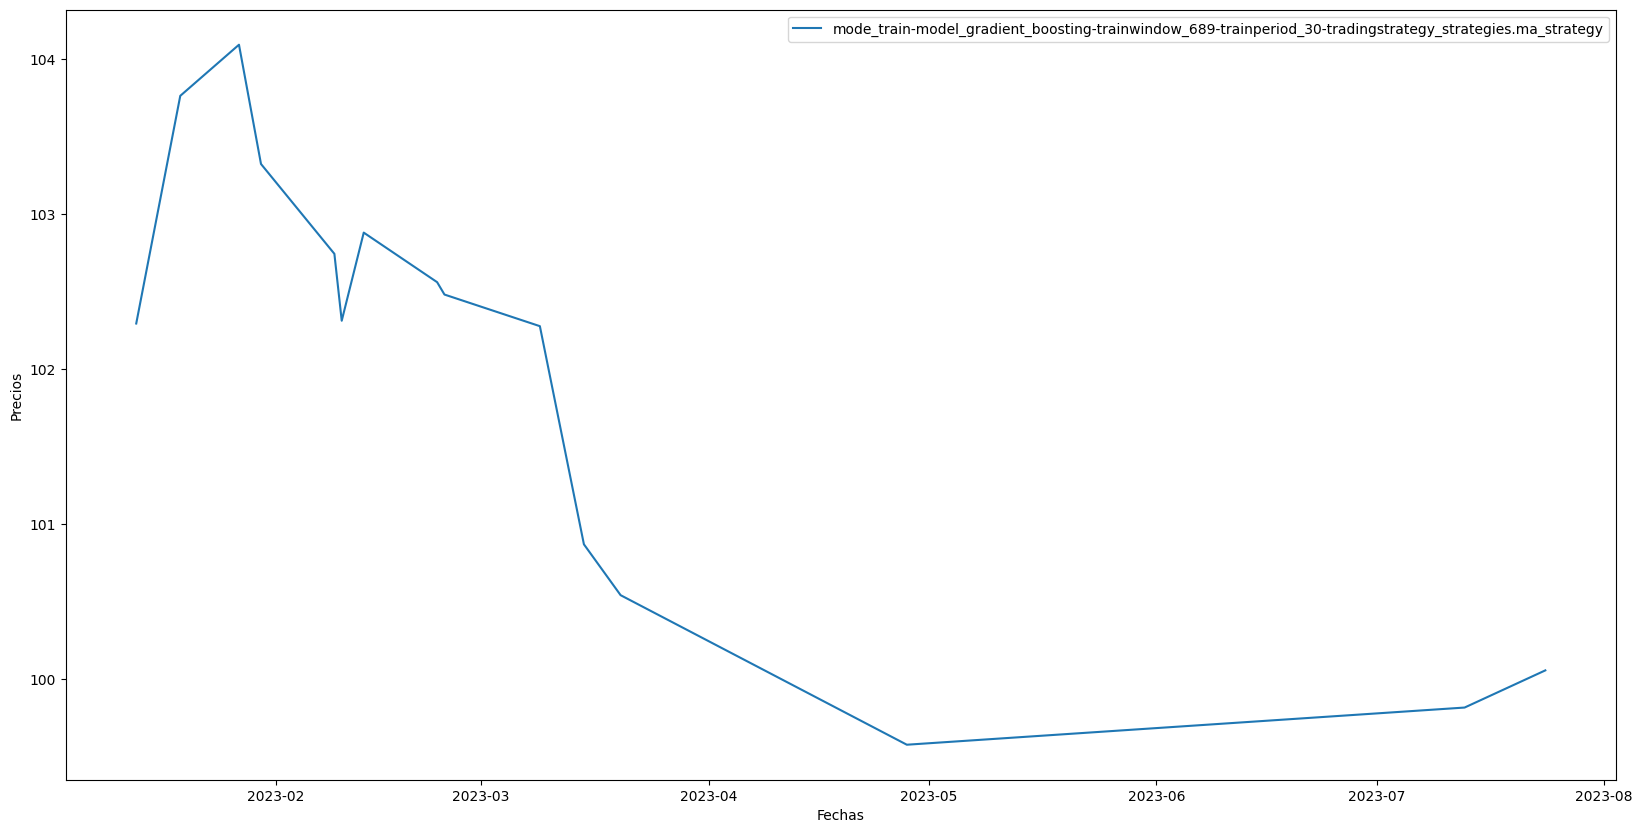

KeyboardInterrupt: Interrupted by user

In [10]:
import time
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

# filter_results = positive_results[positive_results.wallet > 0]
filter_results = results

for path in filter_results.index: 
    print(path)
    # try:

    wallet = pd.read_csv(os.path.join('./data', path, 'wallet.csv'))
    x_wallet = pd.to_datetime(wallet['date'])
    y_wallet = wallet['wallet']  # Datos para la línea
        
    # except:
    #     continue
        
    # Datos de ejemplo
    
    # Crear una figura y ejes
    
    # Agregar la línea
    fig, ax = plt.subplots(figsize=(20, 10))
    
    ax.plot(x_wallet, y_wallet, label=f'{path}')
    
    # Etiquetas de los ejes y leyenda
    ax.set_xlabel('Fechas')
    ax.set_ylabel('Precios')
    ax.legend()
        
        # Mostrar el gráfico
        # print(path)
    plt.show()
    a = input()  # Pausa para la interacción del usuario
    clear_output(wait=True)

In [ ]:
0/0

In [ ]:
# results.loc[
#     [
#         'train_gradient_boosting_train_window_38_train_period_1_trading_strategy_strategies.bband_strategy',
#         'train_gradient_boosting_train_window_38_train_period_1_trading_strategy_strategies.macd_strategy',
#         'train_gradient_boosting_train_window_461_train_period_1_trading_strategy_strategies.bband_strategy',
#         'train_gradient_boosting_train_window_461_train_period_1_trading_strategy_strategies.macd_strategy',
#         'train_logistic_regression_train_window_38_train_period_1_trading_strategy_strategies.bband_strategy'
#     ]
# ]

In [ ]:
results_dict = {}

for path in os.listdir('./data'):
    if not path.endswith('.csv') and path.startswith('test_'):
        print(path)
        results_dict[path] = {}

        try:
            wallet = pd.read_csv(os.path.join('./data', path, 'wallet.csv'))
            results_dict[path]['wallet'] = wallet.tail(1).iloc[0]['wallet']
        except:
            results_dict[path]['wallet'] = 0

        try:
            orders = pd.read_csv(os.path.join('./data', path, 'orders.csv'))
            results_dict[path]['buys'] = orders[orders['open_date'].notna()].shape[0]
            results_dict[path]['sells'] = orders[orders['close_date'].notna()].shape[0]
           
            avg_incomes = orders.groupby('ticker')['profit'].sum().mean()
            results_dict[path]['avg_incomes'] = avg_incomes
            results_dict[path]['good_operations'] = orders[orders['profit'] > 0].shape[0]
            results_dict[path]['bad_operations'] = orders[orders['profit'] <= 0].shape[0]
            results_dict[path]['winning_rate'] = results_dict[path]['good_operations'] / (results_dict[path]['good_operations'] + results_dict[path]['bad_operations']) 

        except:
            results_dict[path]['buys'] = 0
            results_dict[path]['sells'] = 0
            avg_incomes = 0
            results_dict[path]['avg_incomes'] = 0
            results_dict[path]['good_operations'] = 0
            results_dict[path]['bad_operations'] = 0
            results_dict[path]['winning_rate'] = 0

        try:
            train_results = pd.read_csv(os.path.join('./data', path, 'train_results.csv'))
            avg_train_auc = train_results['auc'].mean()
            results_dict[path]['avg_train_auc'] = avg_train_auc
        except:
            results_dict[path]['avg_train_auc'] = 0
            
        try:
            stock_predictions = pd.read_csv(os.path.join('./data', path, 'stock_predictions.csv'))
            true_values = pd.read_csv(os.path.join('./data', path, 'stock_true_values.csv'))

            avg_auc_score = calculate_auc_avg(tickers, stock_predictions, true_values)
            results_dict[path]['avg_test_auc'] = avg_auc_score
        except:
            results_dict[path]['avg_test_auc'] = 0

results = pd.DataFrame.from_dict(results_dict, orient='index')

In [ ]:
results

In [ ]:
results_test.loc[
    [
        'test_gradient_boosting_train_window_38_train_period_1_trading_strategy_strategies.ml_bband_strategy',
        'test_gradient_boosting_train_window_38_train_period_1_trading_strategy_strategies.ml_macd_strategy',
        'test_gradient_boosting_train_window_461_train_period_1_trading_strategy_strategies.ml_bband_strategy',
        'test_gradient_boosting_train_window_461_train_period_1_trading_strategy_strategies.ml_macd_strategy',
        'test_logistic_regression_train_window_38_train_period_1_trading_strategy_strategies.ml_bband_strategy'
    ]
]